In [1]:
import pandas as pd
from catboost import CatBoostClassifier

df = pd.read_csv("../data/processed/engineered_churn_data.csv")

model = CatBoostClassifier()
model.load_model("../models/catboost_churn_model.cbm")

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=0)

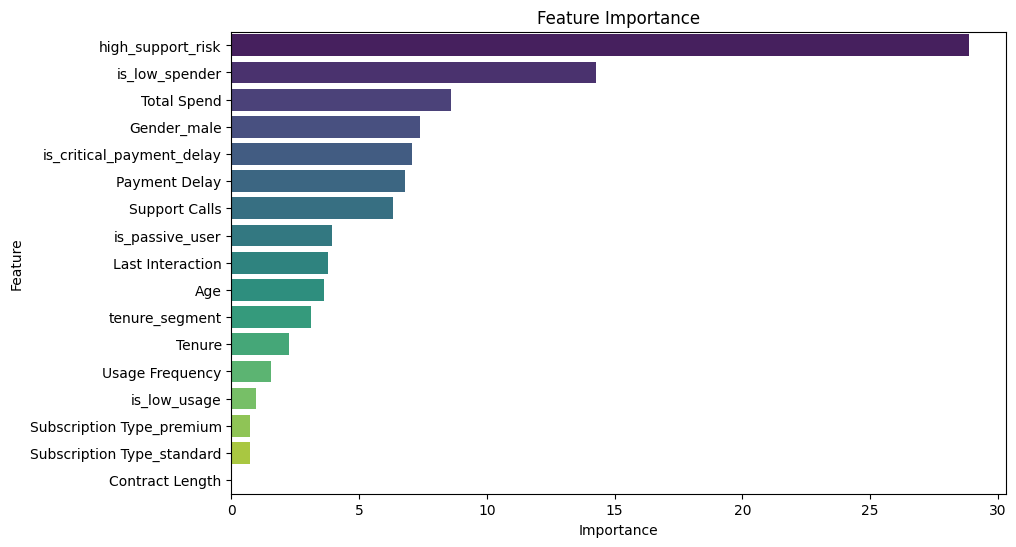

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

fi = model.get_feature_importance()
fn = df.drop('Churn', axis=1).columns

feature_importance_df = pd.DataFrame({'Feature': fn, 'Importance': fi}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
leakage_candidates = [
    'is_critical_payment_delay', 
    'is_low_spender', 
    'high_support_risk',
    'is_passive_user', 
    'is_low_usage'    
]

X_explorer = df.drop(columns=['Churn'] + leakage_candidates)
y_explorer = df['Churn']

from catboost import CatBoostClassifier
explorer_model = CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=0)

explorer_model.fit(X_explorer, y_explorer)

explorer_accuracy = explorer_model.score(X_explorer, y_explorer)
print(f"Explorer Accuracy: {explorer_accuracy:.4f}")

Explorer Accuracy: 0.9877


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_explorer, y_explorer, test_size=0.2, random_state=42
)

explorer_model.fit(X_train, y_train)

print(f"Train: {explorer_model.score(X_train, y_train):.4f}")
print(f"Test:  {explorer_model.score(X_test, y_test):.4f}")

Train: 0.9878
Test:  0.9873


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_explorer)

lr_model_raw = LogisticRegression(max_iter=1000)
lr_model_raw.fit(X_scaled, y_explorer)

print(f"LR Accuracy (Without your features): {lr_model_raw.score(X_scaled, y_explorer):.4f}")

Sir, LR Accuracy (Without your features): 0.8513


In [ ]:
X_full = df.drop(columns=['Churn'])
X_full_scaled = scaler.fit_transform(X_full)

lr_model_powered = LogisticRegression(max_iter=1000)
lr_model_powered.fit(X_full_scaled, y_explorer)

print(f"LR Accuracy (WITH your features): {lr_model_powered.score(X_full_scaled, y_explorer):.4f}")

Sir, LR Accuracy (WITH your features): 0.9677


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_explorer, y_explorer, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

print(f"Train: {lr.score(X_train_scaled, y_train):.4f}")
print(f"Test:  {lr.score(X_test_scaled, y_test):.4f}")

Train: 0.8520
Test:  0.8486


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_explorer, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
print(f"Train: {lr.score(X_train_s, y_train):.4f}")
print(f"Test:  {lr.score(X_test_s, y_test):.4f}")

Train: 0.9679
Test:  0.9671


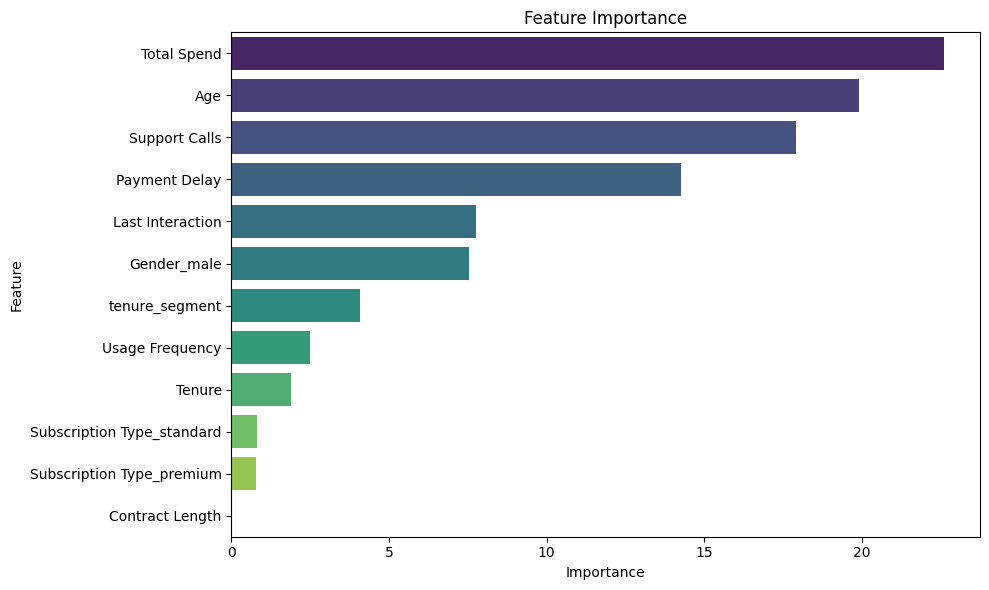

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fi = explorer_model.feature_importances_
fn = X_explorer.columns

feature_importance_df = pd.DataFrame({
    'Feature': fn, 
    'Importance': fi
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, 
            hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [10]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [14]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = explorer_model.predict(X_test)
print(f"Accuracy: \n{accuracy_score(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")
print(f"ROC AUC Score: \n{roc_auc_score(y_test, y_pred)}")

Accuracy: 
0.9872514659679925
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     38044
           1       1.00      0.98      0.99     50123

    accuracy                           0.99     88167
   macro avg       0.99      0.99      0.99     88167
weighted avg       0.99      0.99      0.99     88167

Confusion Matrix: 
[[38044     0]
 [ 1124 48999]]
ROC AUC Score: 
0.9887875825469346


In [18]:
print(df[['Total Spend', 'Payment Delay', 'Support Calls', 'Churn']].groupby('Churn').mean())

       Total Spend  Payment Delay  Support Calls
Churn                                           
0       749.953111      10.015500       1.586418
1       541.285528      15.217729       5.144861
